In [1]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017")
print(client.list_database_names())

db = client['worldCup']
print(db.list_collection_names())        

coll = db['matches']
doc = coll.find_one()
print(doc)                               

['admin', 'config', 'local', 'worldCup']
['matches']
{'_id': ObjectId('69d666c79fdb7a6388ecfda0'), 'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}


In [2]:
datos = list(coll.find(
    {},
    {
    "_id": 0,
    "home_team": 1,
    "away_team": 1,
    "tournament": 1,
    "stage": 1,
    "date": 1,
    "home_score": 1,
    "away_score": 1,
    "venue": 1,
    "elo_diff": 1,
    "winner": 1,
    "home_days_since_last_match": 1,
    "away_days_since_last_match": 1
    }
))
print(datos)

[{'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 15, 0, 0), 'home_team': 'Argentina', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Argentina'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 16, 0, 0), 'home_team': 'Chile', 'away_team': 'Mexico', 'home_score': 3, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 19, 0, 0), 'home_team': 'Chile', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Centenario, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--ur

Hay que armar cada unas de las columnas y tambien extraer sus datos

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from pymongo import MongoClient
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np


client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"]
coll = db["matches"]

datos = list(coll.find({}, {
    "_id": 0,
    "home_team": 1,
    "away_team": 1,
    "tournament": 1,
    "stage": 1,
    "home_score": 1,
    "away_score": 1,
    "elo_diff": 1,
    "home_days_since_last_match": 1,
    "away_days_since_last_match": 1,
    "winner": 1
}))


le_team = LabelEncoder()
le_tournament = LabelEncoder()
le_stage = LabelEncoder()
le_winner = LabelEncoder()

home_team = le_team.fit_transform([d["home_team"] for d in datos])
away_team = le_team.fit_transform([d["away_team"] for d in datos])
tournament = le_tournament.fit_transform([d["tournament"] for d in datos])
stage = le_stage.fit_transform([d["stage"] for d in datos])
y = le_winner.fit_transform([d["winner"] for d in datos])

X = np.column_stack([
    home_team,
    away_team,
    tournament,
    stage,
    [d["elo_diff"] for d in datos],
    [d["home_days_since_last_match"] if d["home_days_since_last_match"] is not None else 0 for d in datos],
    [d["away_days_since_last_match"] if d["away_days_since_last_match"] is not None else 0 for d in datos]
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

KeyError: 'stage'

In [3]:
# Usamos .get(campo, "Unknown") para que si falta el dato, no explote el código
home_team = le_team.fit_transform([d.get("home_team", "Unknown") for d in datos])
away_team = le_team.fit_transform([d.get("away_team", "Unknown") for d in datos])
tournament = le_tournament.fit_transform([d.get("tournament", "Unknown") for d in datos])

# Aquí estaba el fallo del KeyError
stage = le_stage.fit_transform([d.get("stage", "Unknown") for d in datos])

y = le_winner.fit_transform([d.get("winner", "Unknown") for d in datos])

# Para los valores numéricos como elo_diff, si no existen ponemos 0
X = np.column_stack([
    home_team,
    away_team,
    tournament,
    stage,
    [d.get("elo_diff", 0) for d in datos],
    [d.get("home_days_since_last_match", 0) if d.get("home_days_since_last_match") is not None else 0 for d in datos],
    [d.get("away_days_since_last_match", 0) if d.get("away_days_since_last_match") is not None else 0 for d in datos]
])

In [4]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy * 100:.2f}%")

NameError: name 'y_test' is not defined

Predicción real

In [5]:
from numpy import array
home = le_team.transform(["France"])[0]
away = le_team.transform(["Brazil"])[0]
#tournament = le_tournament.transform(["1930--uruguay"])[0]
#stage = le_stage.transform(["Final"])[0]

X_new = array([[home, away, 0, 0, 50, 5, 6]]) # 9 features
X_new = X_new.reshape(1, -1).astype(float)

pred = model.predict(X_new)
winner = le_winner.inverse_transform(pred)
print(winner[0])

NameError: name 'model' is not defined

In [40]:
print("team mapping:", dict(zip(le_team.classes_, le_team.transform(le_team.classes_))))
print("winner classes:", le_winner.classes_)
import numpy as np
print("y counts:", np.bincount(y))

team mapping: {np.str_('Algeria'): np.int64(0), np.str_('Angola'): np.int64(1), np.str_('Argentina'): np.int64(2), np.str_('Australia'): np.int64(3), np.str_('Austria'): np.int64(4), np.str_('Belgium'): np.int64(5), np.str_('Bolivia'): np.int64(6), np.str_('Bosnia-Herzegovina'): np.int64(7), np.str_('Brazil'): np.int64(8), np.str_('Bulgaria'): np.int64(9), np.str_('Cameroon'): np.int64(10), np.str_('Canada'): np.int64(11), np.str_('Chile'): np.int64(12), np.str_('China'): np.int64(13), np.str_('Colombia'): np.int64(14), np.str_('Costa Rica'): np.int64(15), np.str_('Croatia'): np.int64(16), np.str_('Cuba'): np.int64(17), np.str_('Czech Republic'): np.int64(18), np.str_('Czechoslovakia'): np.int64(19), np.str_("Côte d'Ivoire"): np.int64(20), np.str_('Denmark'): np.int64(21), np.str_('Dutch East Indies'): np.int64(22), np.str_('East Germany'): np.int64(23), np.str_('Ecuador'): np.int64(24), np.str_('Egypt'): np.int64(25), np.str_('El Salvador'): np.int64(26), np.str_('England'): np.int64(

BLOQUE MACHINE LEARNING


In [13]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# --- A. CONEXIÓN Y CARGA ---
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"] 
coll = db["matches"]
datos = list(coll.find({}, {"_id": 0}))

# --- B. LIMPIEZA CRÍTICA (Arreglamos las horas en el ganador) ---
for d in datos:
    # Si 'winner' es "13:00 France", esto lo convierte en "France"
    win_val = str(d.get("winner", "Draw"))
    d["winner_clean"] = win_val.split()[-1] if " " in win_val else win_val

# Convertimos a DataFrame de Pandas para manejarlo mejor
df = pd.DataFrame(datos)

# --- C. TRANSFORMACIÓN A NÚMEROS (Label Encoding) ---
le_team = LabelEncoder()
le_winner = LabelEncoder()

# Ajustamos los nombres de equipos (unimos local y visitante para que el número sea el mismo)
todos_los_equipos = pd.concat([df['home_team'], df['away_team']]).unique()
le_team.fit(todos_los_equipos)

# Creamos las columnas numéricas
df['home_idx'] = le_team.transform(df['home_team'])
df['away_idx'] = le_team.transform(df['away_team'])
df['target'] = le_winner.fit_transform(df['winner_clean'])

# --- D. ENTRENAMIENTO ---
# Seleccionamos las columnas que realmente ayudan a predecir
# Usamos elo_diff que es la clave de vuestro proyecto
columnas_x = ['home_idx', 'away_idx', 'elo_diff']
X = df[columnas_x].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- E. RESULTADO ---
y_pred = model.predict(X_test)
print(f"Logrado: Partidos procesados: {len(df)}")
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Logrado: Partidos procesados: 1896
Precisión del modelo: 51.32%


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Entrenamos dos modelos: uno para goles locales y otro para visitantes
model_goals_home = RandomForestRegressor().fit(X_train, df.loc[X_train.index, 'home_score'])
model_goals_away = RandomForestRegressor().fit(X_train, df.loc[X_train.index, 'away_score'])

def predecir_marcador(local, visitante):
    h = le_team.transform([local])[0]
    a = le_team.transform([visitante])[0]
    # Usamos elo_diff = 0 por defecto si no lo tenemos
    input_data = np.array([[h, a, 0]]) 
    
    goles_h = model_goals_home.predict(input_data)[0]
    goles_a = model_goals_away.predict(input_data)[0]
    
    print(f"Predicción marcador: {local} {goles_h:.1f} - {goles_a:.1f} {visitante}")

predecir_marcador("Spain", "Germany")

Predicción marcador: Spain 1.0 - 1.2 Germany


/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


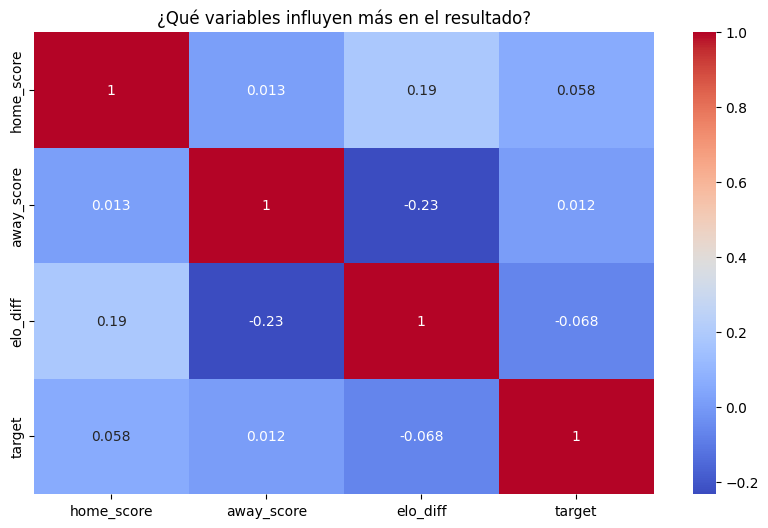

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df[['home_score', 'away_score', 'elo_diff', 'target']].corr(), annot=True, cmap='coolwarm')
plt.title("¿Qué variables influyen más en el resultado?")
plt.show()

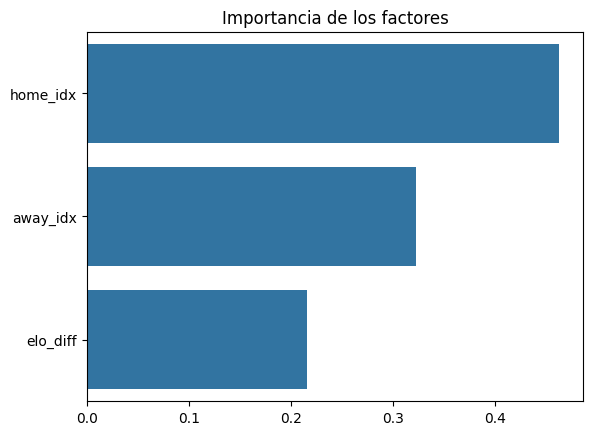

In [15]:
importances = model.feature_importances_
features = columnas_x
sns.barplot(x=importances, y=features)
plt.title("Importancia de los factores")
plt.show()

## SIMULACIÓN MUNDIAL 2026